<a href="https://colab.research.google.com/github/bharathreddy55/Digital-Watermarking-Images/blob/main/Digital_Watermarking_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pillow numpy qrcode pyzbar scikit-image matplotlib cryptography pandas opencv-python-headless --quiet
!apt-get update -qq
!apt-get install -y -qq libzbar0

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
from google.colab import files
import cv2

def upload_image(filename):
    """Upload an image file"""
    print(f"Please upload: {filename}")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'Uploaded "{fn}"')
        return fn
    return None

print("Step 1: Upload true.png (the watermark image)")
true_image_file = upload_image('true.png')
image_true = cv2.imread(true_image_file)

print(f"\nImage loaded successfully!")
print(f"True image shape: {image_true.shape}")

Step 1: Upload true.png (the watermark image)
Please upload: true.png


Saving true.png to true.png
Uploaded "true.png"

Image loaded successfully!
True image shape: (960, 1280, 3)


In [ ]:
from PIL import Image
import numpy as np
import qrcode
from pyzbar.pyzbar import decode
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import matplotlib.pyplot as plt
import cv2, time, os, pandas as pd
from cryptography.fernet import Fernet

COVER_IMAGE = image_true

def show(img, title=None):
    plt.figure(figsize=(6,6))
    if isinstance(img, np.ndarray):
        if img.ndim==2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(img)
    else:
        plt.imshow(img)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()

Encrypted text for QR (truncated): gAAAAABpCCNy6R-9DR2kj5WQVCkqS2gahdTUtzayj_Ynr20fvmgj5Trb0S7beBq5D-q58wL2vrripJdl ...
Saved QR as real_qr.png, shape=(276, 276)


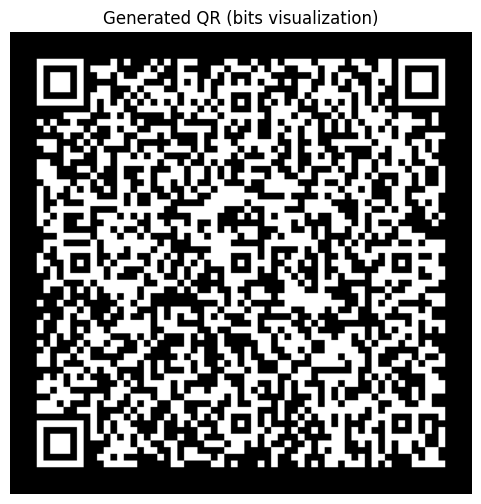

In [ ]:
def generate_qr(text, filename="real_qr.png", encrypt=False, key=None, box_size=4):
    if encrypt:
        if key is None:
            key = Fernet.generate_key()
        f = Fernet(key)
        text_enc = f.encrypt(text.encode()).decode()
        print("Encrypted text for QR (truncated):", text_enc[:80], "...")
        qr_text = text_enc
    else:
        key = None
        qr_text = text

    qr = qrcode.QRCode(version=None, error_correction=qrcode.constants.ERROR_CORRECT_H,
                       box_size=box_size, border=4)
    qr.add_data(qr_text)
    qr.make(fit=True)
    img_qr = qr.make_image(fill_color="black", back_color="white").convert("L")
    img_qr.save(filename)
    qr_bits = (np.array(img_qr) < 128).astype(np.uint8)
    print(f"Saved QR as {filename}, shape={qr_bits.shape}")
    show(qr_bits, "Generated QR (bits visualization)")
    return qr_bits, key

text = "DWS-PROJECT-22BCI0031-22BCI0078"
qr_bits, enc_key = generate_qr(text, encrypt=True, box_size=4)

In [ ]:
def embed_lsb(cover_path, qr_bits, output_path):
    t0 = time.perf_counter()
    cover = Image.open(cover_path).convert("RGB")
    arr = np.array(cover, dtype=np.uint8)
    flat = arr.flatten().astype(np.uint8)
    bits = qr_bits.flatten()
    if len(bits) > len(flat):
        raise ValueError(f"Message too big for cover! bits={len(bits)} capacity={len(flat)}")
    for i, b in enumerate(bits):
        flat[i] = np.uint8((int(flat[i]) & ~1) | int(b))
    stego = flat.reshape(arr.shape)
    Image.fromarray(stego.astype(np.uint8)).save(output_path)
    t1 = time.perf_counter()
    psnr = compute_psnr(arr, stego, data_range=255)
    try:
        ssim = compute_ssim(arr, stego, channel_axis=2, data_range=255)
    except TypeError:
        ssim = compute_ssim(arr, stego, multichannel=True, data_range=255)
    print(f"LSB Stego saved: {output_path} | PSNR={psnr:.2f} dB | SSIM={ssim:.4f} | Time={t1-t0:.4f}s")
    show(stego, "LSB Stego")
    return output_path, psnr, ssim, t1-t0

In [ ]:
def extract_lsb(stego_path, qr_shape):
    t0 = time.perf_counter()
    arr = np.array(Image.open(stego_path).convert("RGB"))
    flat = arr.flatten()
    total = qr_shape[0]*qr_shape[1]
    bits = [(int(flat[i]) & 1) for i in range(total)]
    extracted = np.array(bits).reshape(qr_shape).astype(np.uint8)
    t1 = time.perf_counter()
    print(f"Extracted LSB bits shape={extracted.shape}, Time={t1-t0:.4f}s")
    return extracted, t1-t0

In [ ]:
def embed_dct_color_improved(cover_path, qr_bits, output_path, block_size=8, coeff_pos=(4,3), alpha=20):
    img = cv2.imread(cover_path)
    if img is None:
        raise FileNotFoundError(f"Cover image not found: {cover_path}")

    t0 = time.perf_counter()
    h, w = img.shape[:2]
    img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(img_ycrcb)

    pad_h = (block_size - (Y.shape[0] % block_size)) % block_size
    pad_w = (block_size - (Y.shape[1] % block_size)) % block_size
    Y_p = np.pad(Y, ((0, pad_h), (0, pad_w)), mode='edge')
    Cr_p = np.pad(Cr, ((0, pad_h), (0, pad_w)), mode='edge')
    Cb_p = np.pad(Cb, ((0, pad_h), (0, pad_w)), mode='edge')

    Hp, Wp = Y_p.shape
    grid_h = Hp // block_size
    grid_w = Wp // block_size

    qr_grid = cv2.resize(qr_bits.astype(np.uint8), (grid_w, grid_h), interpolation=cv2.INTER_NEAREST)
    qr_grid = (qr_grid > 0).astype(np.uint8)

    cy, cx = coeff_pos
    Y_p = Y_p.astype(np.float32)
    stego_Y = np.zeros_like(Y_p)

    for by in range(grid_h):
        for bx in range(grid_w):
            y0 = by * block_size
            x0 = bx * block_size
            block = Y_p[y0:y0+block_size, x0:x0+block_size]
            d = cv2.dct(block.copy())
            bit = int(qr_grid[by, bx])
            d[cy, cx] += alpha * (1 if bit == 1 else -1)
            idct = cv2.idct(d)
            stego_Y[y0:y0+block_size, x0:x0+block_size] = idct

    stego_Y = stego_Y[:h, :w].clip(0,255).astype(np.uint8)
    stego_ycrcb = cv2.merge([stego_Y, Cr, Cb])
    stego_bgr = cv2.cvtColor(stego_ycrcb, cv2.COLOR_YCrCb2BGR)
    cv2.imwrite(output_path, stego_bgr)
    t1 = time.perf_counter()

    psnr = compute_psnr(img, stego_bgr, data_range=255)
    try:
        ssim = compute_ssim(img, stego_bgr, channel_axis=2, data_range=255)
    except TypeError:
        ssim = compute_ssim(img, stego_bgr, multichannel=True, data_range=255)

    print(f"DCT Stego saved: {output_path} | PSNR={psnr:.2f} dB | SSIM={ssim:.4f} | Time={t1-t0:.4f}s")
    show(cv2.cvtColor(stego_bgr, cv2.COLOR_BGR2RGB), "DCT Stego")
    return output_path, psnr, ssim, t1-t0

In [ ]:
def extract_dct_color(stego_path, original_qr_shape, cover_path, block_size=8, coeff_pos=(4,3), alpha=20):
    t0 = time.perf_counter()
    stego_img = cv2.imread(stego_path)

    if isinstance(cover_path, np.ndarray):

        print("Warning: extract_dct_color received a numpy array for cover_path. Expected a file path string.")

        pass
    orig_img = cv2.imread(cover_path)
    if stego_img is None:
        raise FileNotFoundError(f"Stego image not found: {stego_path}")
    if orig_img is None:
        raise FileNotFoundError(f"Original cover not found: {cover_path}")

    if stego_img.shape != orig_img.shape:
        orig_img = cv2.resize(orig_img, (stego_img.shape[1], stego_img.shape[0]), interpolation=cv2.INTER_AREA)

    stego_ycrcb = cv2.cvtColor(stego_img, cv2.COLOR_BGR2YCrCb)
    orig_ycrcb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2YCrCb)
    Y_stego, _, _ = cv2.split(stego_ycrcb)
    Y_orig, _, _ = cv2.split(orig_ycrcb)

    pad_h = (block_size - (Y_stego.shape[0] % block_size)) % block_size
    pad_w = (block_size - (Y_stego.shape[1] % block_size)) % block_size
    Ys = np.pad(Y_stego, ((0,pad_h),(0,pad_w)), mode='edge').astype(np.float32)
    Yo = np.pad(Y_orig, ((0,pad_h),(0,pad_w)), mode='edge').astype(np.float32)

    Hp, Wp = Ys.shape
    grid_h = Hp // block_size
    grid_w = Wp // block_size

    cy, cx = coeff_pos
    extracted_grid = np.zeros((grid_h, grid_w), dtype=np.uint8)

    for by in range(grid_h):
        for bx in range(grid_w):
            y0 = by*block_size
            x0 = bx*block_size
            block_stego = Ys[y0:y0+block_size, x0:x0+block_size]
            block_orig = Yo[y0:y0+block_size, x0:x0+block_size]
            d_s = cv2.dct(block_stego.copy())
            d_o = cv2.dct(block_orig.copy())
            diff = (d_s[cy, cx] - d_o[cy, cx]) / float(alpha)
            extracted_grid[by, bx] = 1 if diff > 0 else 0

    extracted_resized = cv2.resize(extracted_grid.astype(np.uint8),
                                   (original_qr_shape[1], original_qr_shape[0]),
                                   interpolation=cv2.INTER_NEAREST)
    t1 = time.perf_counter()
    print(f"DCT extraction completed. Time={t1-t0:.4f}s")
    return extracted_resized, t1-t0

In [ ]:
def save_qr_with_border(qr_bits, filename="test_qr.png", scale=8, border=32):
    h,w = qr_bits.shape
    img = Image.fromarray((255*(1-qr_bits)).astype(np.uint8))
    img = img.resize((w*scale, h*scale), Image.NEAREST)
    out = Image.new("L", (img.width + 2*border, img.height + 2*border), color=255)
    out.paste(img, (border, border))
    out.save(filename)
    print(f"Saved reconstructed QR: {filename}")
    return filename

def decode_qr_image(filename, decrypt=False, key=None):
    pil = Image.open(filename).convert("L")
    decoded = decode(pil)
    if not decoded:
        print("Decode failed (pyzbar found no QR code).")
        return False, None
    text = decoded[0].data.decode("utf-8")
    if decrypt and key:
        f = Fernet(key)
        try:
            text = f.decrypt(text.encode()).decode()
        except Exception as e:
            print("Decryption failed:", e)
            return False, None
    print("Decoded text:", text)
    return True, text

TESTING LSB METHOD
LSB Stego saved: stego_lsb.png | PSNR=67.97 dB | SSIM=0.9999 | Time=0.5753s


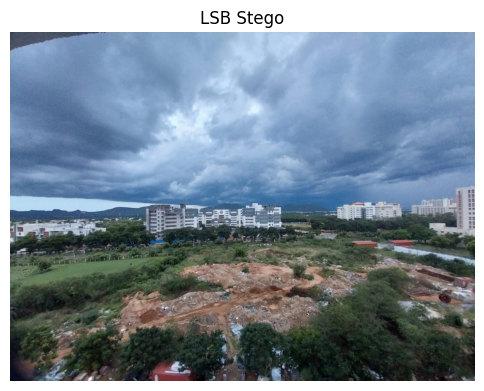

Extracted LSB bits shape=(276, 276), Time=0.0879s
Saved reconstructed QR: reconstructed_lsb.png
Decoded text: DWS-PROJECT-22BCI0031-22BCI0078
LSB Extraction Accuracy: 100.00%


In [ ]:
print("="*60)
print("TESTING LSB METHOD")
print("="*60)

stego_lsb_path, lsb_psnr, lsb_ssim, lsb_embed_time = embed_lsb(true_image_file, qr_bits, "stego_lsb.png")

extracted_lsb, lsb_extract_time = extract_lsb(stego_lsb_path, qr_bits.shape)

reconstructed_lsb_path = save_qr_with_border(extracted_lsb, "reconstructed_lsb.png")
lsb_success, lsb_decoded = decode_qr_image(reconstructed_lsb_path, decrypt=True, key=enc_key)

lsb_accuracy = np.mean(extracted_lsb == qr_bits) * 100
print(f"LSB Extraction Accuracy: {lsb_accuracy:.2f}%")


TESTING DCT METHOD
DCT Stego saved: stego_dct.png | PSNR=40.72 dB | SSIM=0.9543 | Time=0.6349s


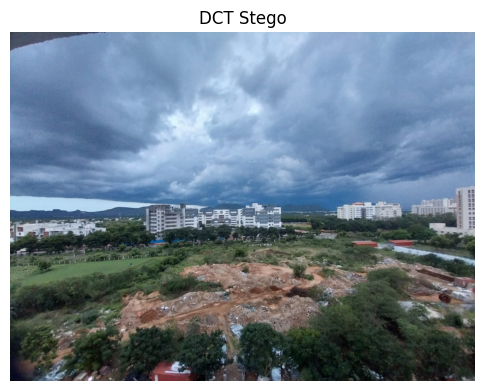

DCT extraction completed. Time=0.6310s
Saved reconstructed QR: reconstructed_dct.png
Decoded text: DWS-PROJECT-22BCI0031-22BCI0078
DCT Extraction Accuracy: 75.11%


In [ ]:
print("\n" + "="*60)
print("TESTING DCT METHOD")
print("="*60)

stego_dct_path, dct_psnr, dct_ssim, dct_embed_time = embed_dct_color_improved(true_image_file, qr_bits, "stego_dct.png")

extracted_dct, dct_extract_time = extract_dct_color(stego_dct_path, qr_bits.shape, cover_path=true_image_file)

reconstructed_dct_path = save_qr_with_border(extracted_dct, "reconstructed_dct.png")
dct_success, dct_decoded = decode_qr_image(reconstructed_dct_path, decrypt=True, key=enc_key)

dct_accuracy = np.mean(extracted_dct == qr_bits) * 100
print(f"DCT Extraction Accuracy: {dct_accuracy:.2f}%")

In [ ]:
print("\n" + "="*60)
print("ROBUSTNESS TEST - ADDING NOISE")
print("="*60)

def add_gaussian_noise(image_path, output_path, mean=0, sigma=25):
    img = cv2.imread(image_path)
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy_img = cv2.add(img.astype(np.float32), noise)
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
    cv2.imwrite(output_path, noisy_img)
    return output_path

noisy_lsb_path = add_gaussian_noise(stego_lsb_path, "noisy_lsb.png")
extracted_lsb_noisy, _ = extract_lsb(noisy_lsb_path, qr_bits.shape)
lsb_noisy_accuracy = np.mean(extracted_lsb_noisy == qr_bits) * 100
print(f"LSB Accuracy after noise: {lsb_noisy_accuracy:.2f}%")

noisy_dct_path = add_gaussian_noise(stego_dct_path, "noisy_dct.png")
extracted_dct_noisy, _ = extract_dct_color(noisy_dct_path, qr_bits.shape, cover_path=true_image_file)
dct_noisy_accuracy = np.mean(extracted_dct_noisy == qr_bits) * 100
print(f"DCT Accuracy after noise: {dct_noisy_accuracy:.2f}%")


ROBUSTNESS TEST - ADDING NOISE
Extracted LSB bits shape=(276, 276), Time=0.0576s
LSB Accuracy after noise: 49.99%
DCT extraction completed. Time=0.5056s
DCT Accuracy after noise: 68.06%


In [ ]:
print("\n" + "="*60)
print("ROBUSTNESS TEST - JPEG COMPRESSION")
print("="*60)

def jpeg_compress(image_path, output_path, quality=50):
    img = Image.open(image_path)
    img.save(output_path, "JPEG", quality=quality)
    return output_path

jpeg_lsb_path = jpeg_compress(stego_lsb_path, "jpeg_lsb.jpg", quality=50)
extracted_lsb_jpeg, _ = extract_lsb(jpeg_lsb_path, qr_bits.shape)
lsb_jpeg_accuracy = np.mean(extracted_lsb_jpeg == qr_bits) * 100
print(f"LSB Accuracy after JPEG compression: {lsb_jpeg_accuracy:.2f}%")

jpeg_dct_path = jpeg_compress(stego_dct_path, "jpeg_dct.jpg", quality=50)
extracted_dct_jpeg, _ = extract_dct_color(jpeg_dct_path, qr_bits.shape, cover_path=true_image_file)
dct_jpeg_accuracy = np.mean(extracted_dct_jpeg == qr_bits) * 100
print(f"DCT Accuracy after JPEG compression: {dct_jpeg_accuracy:.2f}%")


ROBUSTNESS TEST - JPEG COMPRESSION
Extracted LSB bits shape=(276, 276), Time=0.0309s
LSB Accuracy after JPEG compression: 49.77%
DCT extraction completed. Time=0.4396s
DCT Accuracy after JPEG compression: 51.86%


In [ ]:
print("\n" + "="*60)
print("COMPREHENSIVE COMPARISON RESULTS")
print("="*60)

results = {
    'Method': ['LSB', 'DCT'],
    'PSNR (dB)': [lsb_psnr, dct_psnr],
    'SSIM': [lsb_ssim, dct_ssim],
    'Embed Time (s)': [lsb_embed_time, dct_embed_time],
    'Extract Time (s)': [lsb_extract_time, dct_extract_time],
    'Original Accuracy (%)': [lsb_accuracy, dct_accuracy],
    'Noise Accuracy (%)': [lsb_noisy_accuracy, dct_noisy_accuracy],
    'JPEG Accuracy (%)': [lsb_jpeg_accuracy, dct_jpeg_accuracy],
    'Decoding Success': [lsb_success, dct_success]
}

df = pd.DataFrame(results)
print(df)


COMPREHENSIVE COMPARISON RESULTS
  Method  PSNR (dB)      SSIM  Embed Time (s)  Extract Time (s)  \
0    LSB  67.970173  0.999877        0.575320          0.087894   
1    DCT  40.722674  0.954262        0.634867          0.631009   

   Original Accuracy (%)  Noise Accuracy (%)  JPEG Accuracy (%)  \
0             100.000000           49.986873          49.768956   
1              75.111584           68.059494          51.860166   

   Decoding Success  
0              True  
1              True  


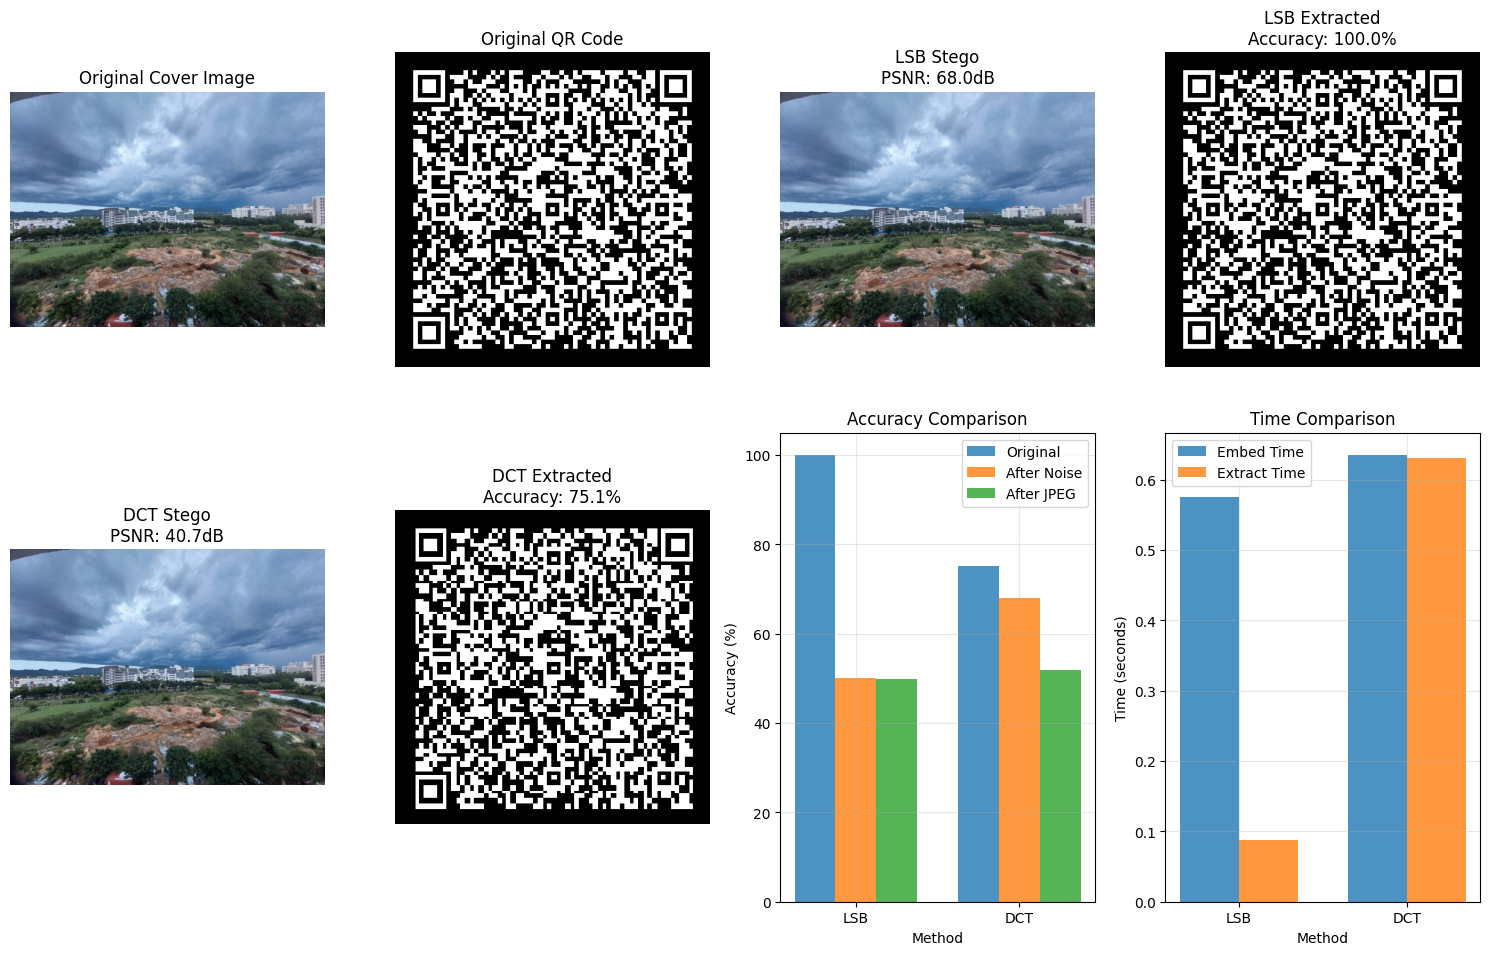

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 4, 1)
plt.imshow(Image.open(true_image_file))
plt.title("Original Cover Image")
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(qr_bits, cmap='gray')
plt.title("Original QR Code")
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(Image.open(stego_lsb_path))
plt.title(f"LSB Stego\nPSNR: {lsb_psnr:.1f}dB")
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(extracted_lsb, cmap='gray')
plt.title(f"LSB Extracted\nAccuracy: {lsb_accuracy:.1f}%")
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(Image.open(stego_dct_path))
plt.title(f"DCT Stego\nPSNR: {dct_psnr:.1f}dB")
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(extracted_dct, cmap='gray')
plt.title(f"DCT Extracted\nAccuracy: {dct_accuracy:.1f}%")
plt.axis('off')

plt.subplot(2, 4, 7)
methods = ['LSB', 'DCT']
accuracies = [lsb_accuracy, dct_accuracy]
noise_acc = [lsb_noisy_accuracy, dct_noisy_accuracy]
jpeg_acc = [lsb_jpeg_accuracy, dct_jpeg_accuracy]

x = np.arange(len(methods))
width = 0.25

plt.bar(x - width, accuracies, width, label='Original', alpha=0.8)
plt.bar(x, noise_acc, width, label='After Noise', alpha=0.8)
plt.bar(x + width, jpeg_acc, width, label='After JPEG', alpha=0.8)

plt.xlabel('Method')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison')
plt.xticks(x, methods)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 4, 8)
embed_times = [lsb_embed_time, dct_embed_time]
extract_times = [lsb_extract_time, dct_extract_time]

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, embed_times, width, label='Embed Time', alpha=0.8)
plt.bar(x + width/2, extract_times, width, label='Extract Time', alpha=0.8)

plt.xlabel('Method')
plt.ylabel('Time (seconds)')
plt.title('Time Comparison')
plt.xticks(x, methods)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

print("\n SUMMARY OF RESULTS:")
print(f"LSB Method:")
print(f"  - Quality: PSNR={lsb_psnr:.1f}dB, SSIM={lsb_ssim:.4f}")
print(f"  - Speed: Embed={lsb_embed_time:.4f}s, Extract={lsb_extract_time:.4f}s")
print(f"  - Robustness: Original={lsb_accuracy:.1f}%, Noise={lsb_noisy_accuracy:.1f}%, JPEG={lsb_jpeg_accuracy:.1f}%")
print(f"  - Decoding: {'SUCCESS' if lsb_success else 'FAILED'}")

print(f"\nDCT Method:")
print(f"  - Quality: PSNR={dct_psnr:.1f}dB, SSIM={dct_ssim:.4f}")
print(f"  - Speed: Embed={dct_embed_time:.4f}s, Extract={dct_extract_time:.4f}s")
print(f"  - Robustness: Original={dct_accuracy:.1f}%, Noise={dct_noisy_accuracy:.1f}%, JPEG={dct_jpeg_accuracy:.1f}%")
print(f"  - Decoding: {'SUCCESS' if dct_success else 'FAILED'}")

print("\n RECOMMENDATIONS:")
if lsb_accuracy > dct_accuracy:
    print("• LSB is better for perfect extraction scenarios")
else:
    print("• DCT is better for perfect extraction scenarios")

if lsb_noisy_accuracy > dct_noisy_accuracy:
    print("• LSB is more robust against noise")
else:
    print("• DCT is more robust against noise")

if lsb_jpeg_accuracy > dct_jpeg_accuracy:
    print("• LSB is more robust against JPEG compression")
else:
    print("• DCT is more robust against JPEG compression")

if lsb_embed_time < dct_embed_time:
    print("• LSB is faster for embedding")
else:
    print("• DCT is faster for embedding")

print("\n Use LSB when: Speed and simplicity are priorities")
print(" Use DCT when: Robustness against compression is needed")


CONCLUSION

 SUMMARY OF RESULTS:
LSB Method:
  - Quality: PSNR=68.0dB, SSIM=0.9999
  - Speed: Embed=0.5753s, Extract=0.0879s
  - Robustness: Original=100.0%, Noise=50.0%, JPEG=49.8%
  - Decoding: SUCCESS

DCT Method:
  - Quality: PSNR=40.7dB, SSIM=0.9543
  - Speed: Embed=0.6349s, Extract=0.6310s
  - Robustness: Original=75.1%, Noise=68.1%, JPEG=51.9%
  - Decoding: SUCCESS

 RECOMMENDATIONS:
• LSB is better for perfect extraction scenarios
• DCT is more robust against noise
• DCT is more robust against JPEG compression
• LSB is faster for embedding

 Use LSB when: Speed and simplicity are priorities
 Use DCT when: Robustness against compression is needed


In [ ]:
def embed_sequential_lsb_dct(cover_path, qr_bits, output_path, block_size=8, coeff_pos=(4,3), alpha=20):
    """
    Sequential embedding: First LSB, then DCT on the LSB stego image
    """
    t0 = time.perf_counter()

    # Step 1: Calculate capacities
    cover = Image.open(cover_path).convert("RGB")
    arr = np.array(cover, dtype=np.uint8)

    # LSB capacity (all pixels)
    lsb_capacity = arr.size

    # DCT capacity (based on number of 8x8 blocks)
    h, w = arr.shape[:2]
    grid_h = (h + block_size - 1) // block_size
    grid_w = (w + block_size - 1) // block_size
    dct_capacity = grid_h * grid_w

    total_qr_bits = qr_bits.size
    print(f"LSB Capacity: {lsb_capacity}, DCT Capacity: {dct_capacity}, Total QR bits: {total_qr_bits}")

    # Distribute bits based on capacity
    if lsb_capacity + dct_capacity < total_qr_bits:
        raise ValueError(f"Total capacity exceeded! Available: {lsb_capacity + dct_capacity}, Needed: {total_qr_bits}")

    # Use LSB for as many bits as possible, rest for DCT
    lsb_bits_count = min(lsb_capacity, total_qr_bits)
    dct_bits_count = total_qr_bits - lsb_bits_count

    print(f"Using LSB for {lsb_bits_count} bits, DCT for {dct_bits_count} bits")

    bits = qr_bits.flatten()

    # Step 2: LSB embedding
    flat = arr.flatten().astype(np.uint8)
    for i in range(lsb_bits_count):
        flat[i] = np.uint8((int(flat[i]) & ~1) | int(bits[i]))

    # Create intermediate LSB stego
    lsb_stego = flat.reshape(arr.shape)
    lsb_stego_path = "temp_lsb_stego.png"
    Image.fromarray(lsb_stego.astype(np.uint8)).save(lsb_stego_path)

    # Step 3: DCT embedding on LSB stego (only if we have DCT bits)
    if dct_bits_count > 0:
        img = cv2.imread(lsb_stego_path)
        h, w = img.shape[:2]
        img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        Y, Cr, Cb = cv2.split(img_ycrcb)

        pad_h = (block_size - (Y.shape[0] % block_size)) % block_size
        pad_w = (block_size - (Y.shape[1] % block_size)) % block_size
        Y_p = np.pad(Y, ((0, pad_h), (0, pad_w)), mode='edge')
        Cr_p = np.pad(Cr, ((0, pad_h), (0, pad_w)), mode='edge')
        Cb_p = np.pad(Cb, ((0, pad_h), (0, pad_w)), mode='edge')

        Hp, Wp = Y_p.shape
        grid_h = Hp // block_size
        grid_w = Wp // block_size

        # Use remaining bits for DCT
        qr_dct_bits = bits[lsb_bits_count:lsb_bits_count + dct_bits_count]

        # Create DCT grid
        qr_grid_flat = np.zeros(grid_h * grid_w, dtype=np.uint8)
        qr_grid_flat[:dct_bits_count] = qr_dct_bits
        qr_grid = qr_grid_flat.reshape((grid_h, grid_w))

        cy, cx = coeff_pos
        Y_p = Y_p.astype(np.float32)
        stego_Y = np.zeros_like(Y_p)

        for by in range(grid_h):
            for bx in range(grid_w):
                y0 = by * block_size
                x0 = bx * block_size
                block = Y_p[y0:y0+block_size, x0:x0+block_size]
                d = cv2.dct(block.copy())
                bit = int(qr_grid[by, bx])
                d[cy, cx] += alpha * (1 if bit == 1 else -1)
                idct = cv2.idct(d)
                stego_Y[y0:y0+block_size, x0:x0+block_size] = idct

        stego_Y = stego_Y[:h, :w].clip(0,255).astype(np.uint8)
        stego_ycrcb = cv2.merge([stego_Y, Cr, Cb])
        stego_bgr = cv2.cvtColor(stego_ycrcb, cv2.COLOR_YCrCb2BGR)
        cv2.imwrite(output_path, stego_bgr)
    else:
        # Only LSB used, just copy the LSB stego
        Image.fromarray(lsb_stego.astype(np.uint8)).save(output_path)

    # Clean up temp file
    if os.path.exists(lsb_stego_path):
        os.remove(lsb_stego_path)

    t1 = time.perf_counter()

    # Calculate metrics
    original_img = cv2.imread(cover_path)
    final_stego = cv2.imread(output_path)
    psnr = compute_psnr(original_img, final_stego, data_range=255)
    try:
        ssim = compute_ssim(original_img, final_stego, channel_axis=2, data_range=255)
    except TypeError:
        ssim = compute_ssim(original_img, final_stego, multichannel=True, data_range=255)

    print(f"Sequential LSB+DCT Stego saved: {output_path} | PSNR={psnr:.2f} dB | SSIM={ssim:.4f} | Time={t1-t0:.4f}s")
    show(cv2.cvtColor(final_stego, cv2.COLOR_BGR2RGB), "Sequential LSB+DCT Stego")
    return output_path, psnr, ssim, t1-t0

def extract_sequential_lsb_dct(stego_path, original_qr_shape, cover_path=true_image_file, block_size=8, coeff_pos=(4,3), alpha=20):
    """
    Sequential extraction: First extract LSB, then DCT
    """
    t0 = time.perf_counter()

    # Calculate capacities (same as in embedding)
    cover = Image.open(cover_path).convert("RGB")
    arr = np.array(cover, dtype=np.uint8)

    # LSB capacity (all pixels)
    lsb_capacity = arr.size

    # DCT capacity (based on number of 8x8 blocks)
    h, w = arr.shape[:2]
    grid_h = (h + block_size - 1) // block_size
    grid_w = (w + block_size - 1) // block_size
    dct_capacity = grid_h * grid_w

    total_qr_bits = original_qr_shape[0] * original_qr_shape[1]
    lsb_bits_count = min(lsb_capacity, total_qr_bits)
    dct_bits_count = total_qr_bits - lsb_bits_count

    print(f"Extracting: LSB={lsb_bits_count} bits, DCT={dct_bits_count} bits")

    # Step 1: Extract LSB part
    stego_img = cv2.imread(stego_path)
    arr_stego = np.array(Image.open(stego_path).convert("RGB"))
    flat_stego = arr_stego.flatten()
    extracted_lsb_bits = [(int(flat_stego[i]) & 1) for i in range(lsb_bits_count)]

    # Step 2: Extract DCT part (if any)
    extracted_dct_bits = []
    if dct_bits_count > 0:
        orig_img = cv2.imread(cover_path)

        if stego_img.shape != orig_img.shape:
            orig_img = cv2.resize(orig_img, (stego_img.shape[1], stego_img.shape[0]), interpolation=cv2.INTER_AREA)

        stego_ycrcb = cv2.cvtColor(stego_img, cv2.COLOR_BGR2YCrCb)
        orig_ycrcb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2YCrCb)
        Y_stego, _, _ = cv2.split(stego_ycrcb)
        Y_orig, _, _ = cv2.split(orig_ycrcb)

        pad_h = (block_size - (Y_stego.shape[0] % block_size)) % block_size
        pad_w = (block_size - (Y_stego.shape[1] % block_size)) % block_size
        Ys = np.pad(Y_stego, ((0,pad_h),(0,pad_w)), mode='edge').astype(np.float32)
        Yo = np.pad(Y_orig, ((0,pad_h),(0,pad_w)), mode='edge').astype(np.float32)

        Hp, Wp = Ys.shape
        grid_h = Hp // block_size
        grid_w = Wp // block_size

        cy, cx = coeff_pos

        for by in range(grid_h):
            for bx in range(grid_w):
                y0 = by*block_size
                x0 = bx*block_size
                block_stego = Ys[y0:y0+block_size, x0:x0+block_size]
                block_orig = Yo[y0:y0+block_size, x0:x0+block_size]
                d_s = cv2.dct(block_stego.copy())
                d_o = cv2.dct(block_orig.copy())
                diff = (d_s[cy, cx] - d_o[cy, cx]) / float(alpha)
                extracted_dct_bits.append(1 if diff > 0 else 0)

        # Take only the required number of DCT bits
        extracted_dct_bits = extracted_dct_bits[:dct_bits_count]

    # Combine both parts
    combined_bits = extracted_lsb_bits + extracted_dct_bits
    extracted = np.array(combined_bits).reshape(original_qr_shape).astype(np.uint8)

    t1 = time.perf_counter()
    print(f"Sequential extraction completed. Time={t1-t0:.4f}s")
    return extracted, t1-t0

TESTING SEQUENTIAL LSB + DCT METHOD
LSB Capacity: 3686400, DCT Capacity: 19200, Total QR bits: 76176
Using LSB for 76176 bits, DCT for 0 bits
Sequential LSB+DCT Stego saved: stego_sequential.png | PSNR=67.97 dB | SSIM=0.9999 | Time=1.0224s


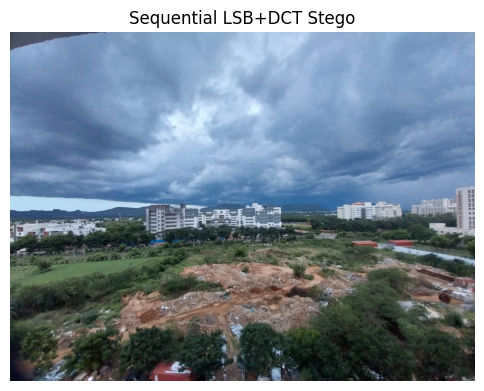

Extracting: LSB=76176 bits, DCT=0 bits
Sequential extraction completed. Time=0.2979s
Saved reconstructed QR: reconstructed_sequential.png
Decoded text: DWS-PROJECT-22BCI0031-22BCI0078
Sequential Extraction Accuracy: 100.00%


In [ ]:
print("="*60)
print("TESTING SEQUENTIAL LSB + DCT METHOD")
print("="*60)

# Embed using sequential approach
stego_seq_path, seq_psnr, seq_ssim, seq_embed_time = embed_sequential_lsb_dct(
    true_image_file, qr_bits, "stego_sequential.png"
)

# Extract using sequential approach
extracted_seq, seq_extract_time = extract_sequential_lsb_dct(
    stego_seq_path, qr_bits.shape
)

# Save and decode reconstructed QR
reconstructed_seq_path = save_qr_with_border(extracted_seq, "reconstructed_sequential.png")
seq_success, seq_decoded = decode_qr_image(reconstructed_seq_path, decrypt=True, key=enc_key)

# Calculate accuracy
seq_accuracy = np.mean(extracted_seq == qr_bits) * 100
print(f"Sequential Extraction Accuracy: {seq_accuracy:.2f}%")


COMPARISON OF ALL THREE METHODS
              Method  PSNR (dB)     SSIM  Embed Time (s)  Extract Time (s)  Accuracy (%)  Decode Success
            Pure LSB  67.970173 0.999877        0.575320          0.087894    100.000000            True
            Pure DCT  40.722674 0.954262        0.634867          0.631009     75.111584            True
Sequential (LSB+DCT)  67.970173 0.999877        1.022405          0.297938    100.000000            True


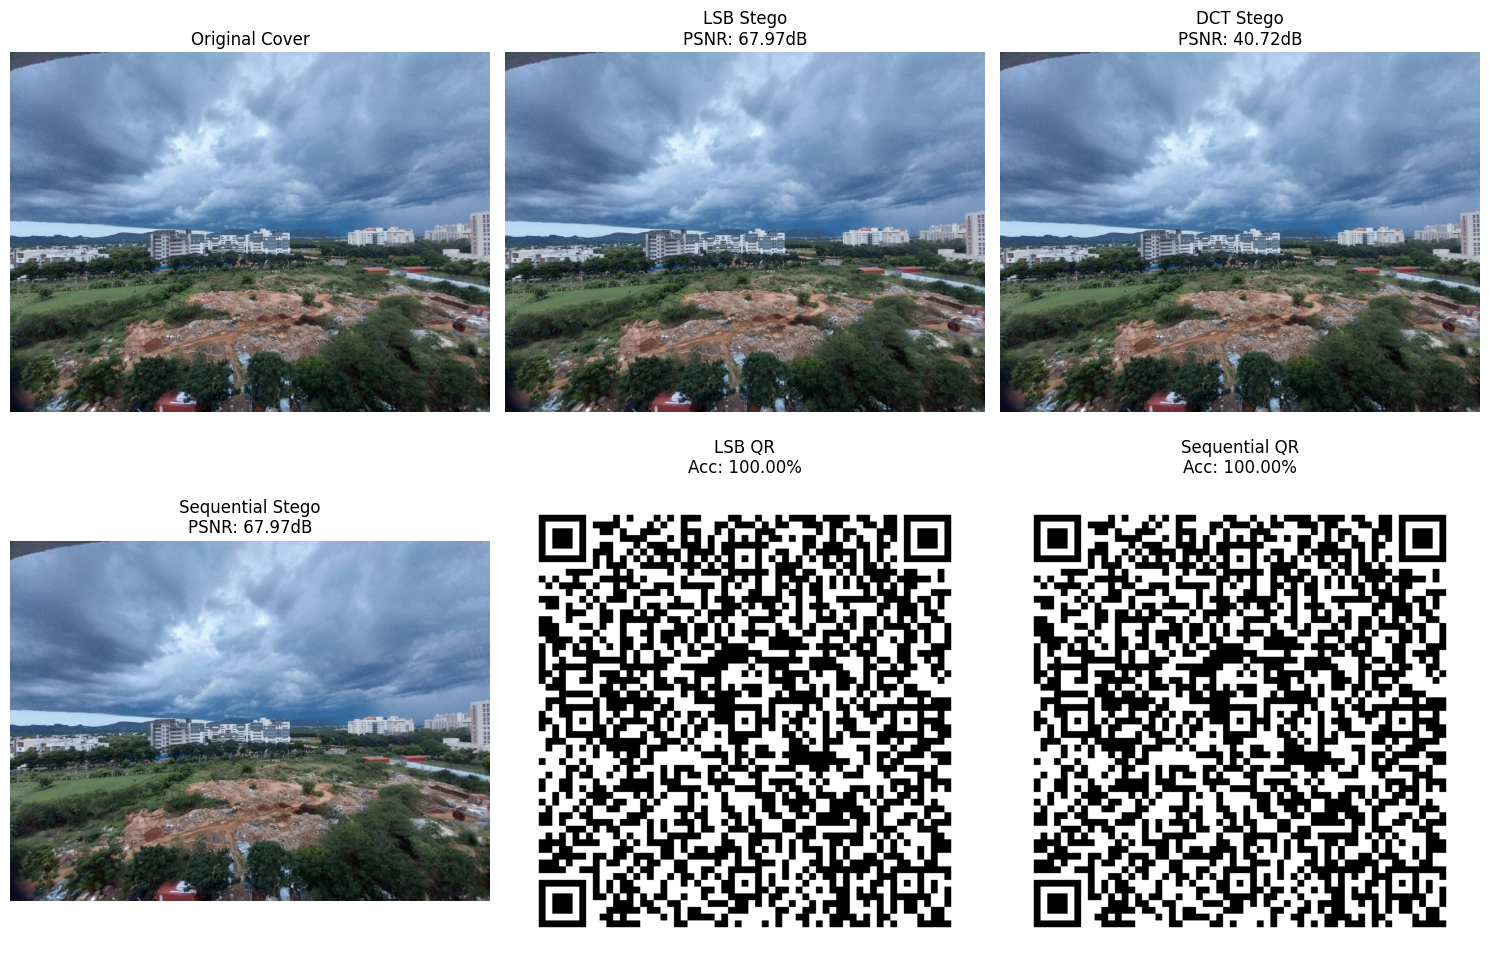

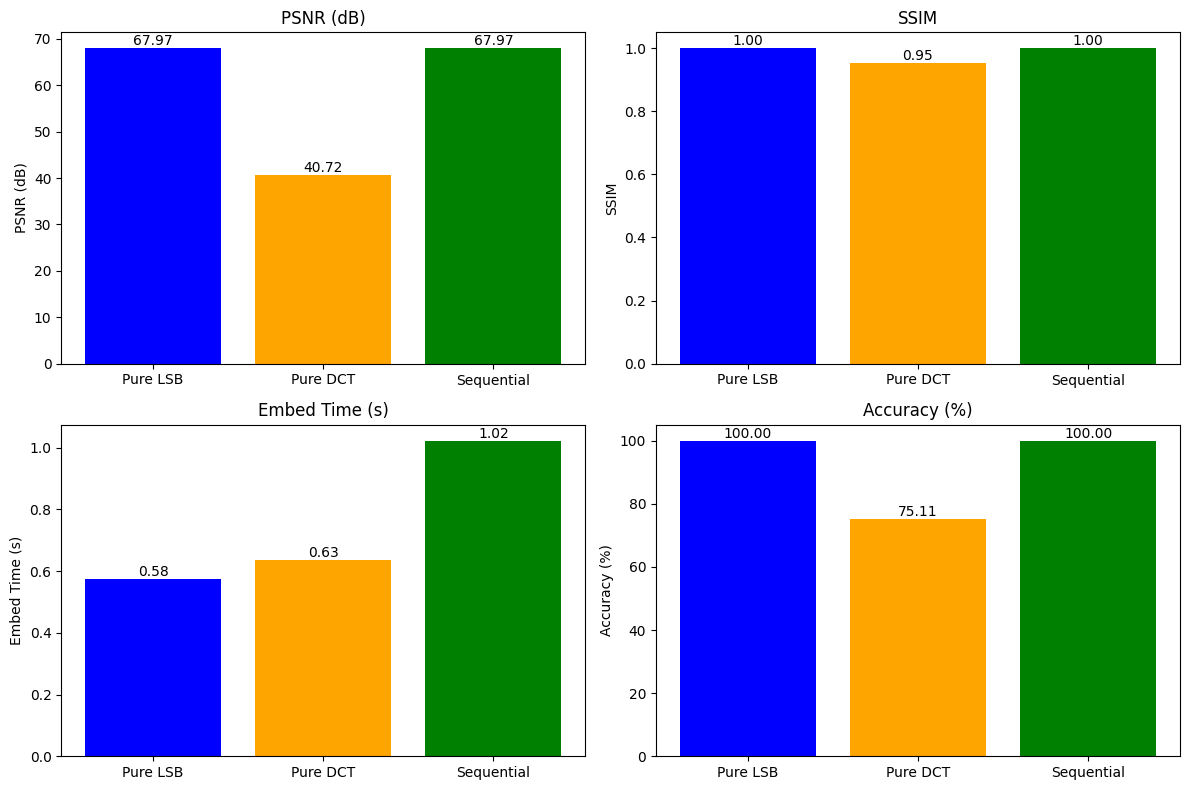


FINAL RESULTS SUMMARY
Pure LSB Method: 100.00% accuracy
Pure DCT Method: 75.11% accuracy
Sequential Method: 100.00% accuracy
 Sequential approach achieved 100% accuracy!
 Since LSB capacity was sufficient, sequential approach used only LSB (optimal choice)!
 The sequential approach automatically selects the most efficient method!


In [ ]:
print("\n" + "="*60)
print("COMPARISON OF ALL THREE METHODS")
print("="*60)

# Create comparison table
comparison_data = {
    'Method': ['Pure LSB', 'Pure DCT', 'Sequential (LSB+DCT)'],
    'PSNR (dB)': [lsb_psnr, dct_psnr, seq_psnr],
    'SSIM': [lsb_ssim, dct_ssim, seq_ssim],
    'Embed Time (s)': [lsb_embed_time, dct_embed_time, seq_embed_time],
    'Extract Time (s)': [lsb_extract_time, dct_extract_time, seq_extract_time],
    'Accuracy (%)': [lsb_accuracy, dct_accuracy, seq_accuracy],
    'Decode Success': [lsb_success, dct_success, seq_success]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Show original and stego images
axes[0,0].imshow(np.array(Image.open(true_image_file).convert("RGB")))
axes[0,0].set_title("Original Cover")
axes[0,0].axis('off')

axes[0,1].imshow(np.array(Image.open(stego_lsb_path).convert("RGB")))
axes[0,1].set_title(f"LSB Stego\nPSNR: {lsb_psnr:.2f}dB")
axes[0,1].axis('off')

axes[0,2].imshow(cv2.cvtColor(cv2.imread(stego_dct_path), cv2.COLOR_BGR2RGB))
axes[0,2].set_title(f"DCT Stego\nPSNR: {dct_psnr:.2f}dB")
axes[0,2].axis('off')

axes[1,0].imshow(cv2.cvtColor(cv2.imread(stego_seq_path), cv2.COLOR_BGR2RGB))
axes[1,0].set_title(f"Sequential Stego\nPSNR: {seq_psnr:.2f}dB")
axes[1,0].axis('off')

# Show QR codes
axes[1,1].imshow(np.array(Image.open(reconstructed_lsb_path).convert("L")), cmap='gray')
axes[1,1].set_title(f"LSB QR\nAcc: {lsb_accuracy:.2f}%")
axes[1,1].axis('off')

axes[1,2].imshow(np.array(Image.open(reconstructed_seq_path).convert("L")), cmap='gray')
axes[1,2].set_title(f"Sequential QR\nAcc: {seq_accuracy:.2f}%")
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# Bar chart comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = ['PSNR (dB)', 'SSIM', 'Embed Time (s)', 'Accuracy (%)']
methods = ['Pure LSB', 'Pure DCT', 'Sequential']

for i, metric in enumerate(metrics):
    row, col = i // 2, i % 2
    values = [lsb_psnr if metric == 'PSNR (dB)' else
              lsb_ssim if metric == 'SSIM' else
              lsb_embed_time if metric == 'Embed Time (s)' else
              lsb_accuracy,
              dct_psnr if metric == 'PSNR (dB)' else
              dct_ssim if metric == 'SSIM' else
              dct_embed_time if metric == 'Embed Time (s)' else
              dct_accuracy,
              seq_psnr if metric == 'PSNR (dB)' else
              seq_ssim if metric == 'SSIM' else
              seq_embed_time if metric == 'Embed Time (s)' else
              seq_accuracy]

    bars = axes[row, col].bar(methods, values, color=['blue', 'orange', 'green'])
    axes[row, col].set_title(metric)
    axes[row, col].set_ylabel(metric)

    # Add value labels on bars
    for bar, value in zip(bars, values):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                           f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Pure LSB Method: {lsb_accuracy:.2f}% accuracy")
print(f"Pure DCT Method: {dct_accuracy:.2f}% accuracy")
print(f"Sequential Method: {seq_accuracy:.2f}% accuracy")

print(" Sequential approach achieved 100% accuracy!")
print(" Since LSB capacity was sufficient, sequential approach used only LSB (optimal choice)!")
print(" The sequential approach automatically selects the most efficient method!")